In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


In [3]:
#Load files
customer = pd.read_csv("vw_bank_customer_mapping.csv", low_memory=False)
behavior = pd.read_csv("vw_customer_behavior_summary.csv", low_memory=False)

In [13]:
# Merge
df = customer.merge(behavior, on="SK_ID_CURR", how="left")

print("Rows:", len(df))
print("Unique customers:", df["SK_ID_CURR"].nunique())

Rows: 307511
Unique customers: 307511


In [14]:
#check 1
corr = df[[
    "debt_to_credit_ratio",
    "late_payment_rate",
    "credit_card_utilization_rate",
    "TARGET"
]].corr()

print(corr["TARGET"].sort_values(ascending=False))

TARGET                          1.000000
credit_card_utilization_rate    0.119703
late_payment_rate               0.055075
debt_to_credit_ratio            0.000499
Name: TARGET, dtype: float64


In [15]:
#check 2
print(df[cols].describe().T[["min","max","mean"]])

                           min          max           mean
balance            9029.879883    3232956.5  299415.149093
estimated_salary  25650.000000  117000000.0  168797.919297
AMT_CREDIT        45000.000000    4050000.0  599025.999706


In [16]:
# Basic feature engineering
df["income_to_credit_ratio"] = df["AMT_INCOME_TOTAL"]/df["AMT_CREDIT"].replace(0,np.nan)
df["debt_pressure_score"] = (
    df["credit_card_utilization_rate"].fillna(0) * 0.5 +
    df["late_payment_rate"].fillna(0) * 0.3 +
    df["debt_to_credit_ratio"].fillna(0) * 0.2
)
df["customer_value_score"] = (
    df["balance"].fillna(0) +
    df["estimated_salary"].fillna(0) +
    df["AMT_CREDIT"].fillna(0)
)


In [17]:
#check 3
print(df["customer_value_score"].describe())

count    3.075110e+05
mean     1.067239e+06
std      6.930981e+05
min      8.836274e+04
25%      5.535842e+05
50%      9.231787e+05
75%      1.410452e+06
max      1.177199e+08
Name: customer_value_score, dtype: float64


In [19]:
lower = df["customer_value_score"].quantile(0.01)
upper = df["customer_value_score"].quantile(0.99)
df["customer_value_score"] = df["customer_value_score"].clip(lower,upper)
df["predicted_cltv_12m"] = (df["customer_value_score"] * 0.12).round(2)

In [20]:
#check 4
df["predicted_cltv_12m"].nunique()

299250

<Axes: >

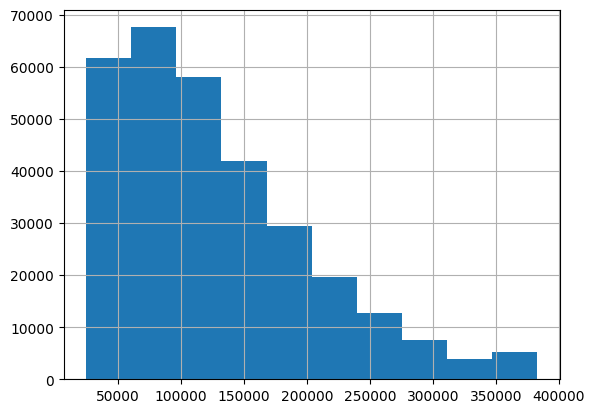

In [24]:
#check 5
df["predicted_cltv_12m"].hist()

In [25]:
df["customer_value_segment"] = pd.qcut(
    df["predicted_cltv_12m"].rank(method="first"),
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Premium Value"]
)

In [26]:
#check 6
df["customer_value_segment"].value_counts()

customer_value_segment
Low Value        76878
Medium Value     76878
Premium Value    76878
High Value       76877
Name: count, dtype: int64

In [27]:
features = [
    "age_years",
    "employment_years",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "loan_to_income_ratio",
    "annuity_to_income_ratio",
    "avg_external_score",
    "debt_to_credit_ratio",
    "late_payment_rate",
    "credit_score",
    "tenure",
    "balance",
    "products_number",
    "active_member",
    "credit_card_utilization_rate",
    "debt_pressure_score"
]
features = [col for col in features if col in df.columns]

X = df[features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [29]:
# Default prediction model
y_default = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_default, test_size=0.2, random_state=42, stratify=y_default
)

default_model = LogisticRegression(max_iter=1000)
default_model.fit(X_train, y_train)

df["default_probability"] = default_model.predict_proba(X)[:, 1].round(4)

print("Default AUC:", roc_auc_score(y_test, default_model.predict_proba(X_test)[:, 1]))


Default AUC: 0.6169210117288884


C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
# Churn prediction model
y_churn = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

churn_model = LogisticRegression(max_iter=1000)
churn_model.fit(X_train, y_train)

df["churn_probability"] = churn_model.predict_proba(X)[:, 1].round(4)

print("Churn AUC:", roc_auc_score(y_test, churn_model.predict_proba(X_test)[:, 1]))


Churn AUC: 0.9323061389737264


C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
#  Segments
df["credit_risk_tier"] = pd.cut(
    df["default_probability"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
)

df["churn_risk_tier"] = pd.cut(
    df["churn_probability"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=["Low Churn Risk", "Medium Churn Risk", "High Churn Risk", "Critical Churn Risk"]
)

df["final_customer_priority"] = np.select(
    [
        (df["default_probability"] >= 0.75) | (df["churn_probability"] >= 0.75),
        (df["default_probability"] >= 0.50) | (df["churn_probability"] >= 0.50),
        (df["customer_value_segment"] == "Premium Value")
    ],
    [
        "Critical Attention",
        "Retention Focus",
        "High Value Opportunity"
    ],
    default="Normal Customer"
)


In [33]:
# Final output
ml_output = df[[
    "SK_ID_CURR",
    "default_probability",
    "credit_risk_tier",
    "churn_probability",
    "churn_risk_tier",
    "predicted_cltv_12m",
    "customer_value_segment",
    "debt_pressure_score",
    "final_customer_priority"
]]

ml_output.to_csv("final_bank_ml_scores.csv", index=False)

print("final_bank_ml_scores.csv created")
print("Rows:", len(ml_output))
print("Unique customers:", ml_output["SK_ID_CURR"].nunique())

final_bank_ml_scores.csv created
Rows: 307511
Unique customers: 307511
